# Lokaler Ansatz: Klassifikation von Supportanfragen via lokal betriebenem LLM

Dieses Notebook bildet den lokalen Gegenpart zum cloudbasierten Ansatz ab. Wurde die
Klassifikation dort an ein über das Internet angesprochenes Large Language Model (Claude)
delegiert, so wird sie hier von einem Sprachmodell übernommen, das vollständig auf dem
eigenen Rechner ausgeführt wird. Verwendet wird hierzu *Ollama*, eine Laufzeitumgebung,
die das Modell verwaltet und ihre Funktionalität über eine lokale HTTP-Schnittstelle
bereitstellt. Auf diese Weise bleibt die Aufrufstruktur – ein Request mit Prompt, eine
Antwort des Modells – derjenigen des Cloud-Ansatzes nachempfunden, während die Inferenz
nun ausschließlich auf der lokalen Hardware stattfindet und die Ticketdaten das Gerät zu
keinem Zeitpunkt verlassen.

Damit der Vergleich zwischen beiden Ansätzen belastbar ist, werden **derselbe Datensatz
(Datensatz 4, `dataset-tickets-multi-lang-4-20k.csv`)**, **dieselbe Zielgröße (`queue`)**,
dieselbe stratifizierte Stichprobe und derselbe Klassifikationsprompt verwendet wie im
Cloud-Notebook. Lediglich die ausführende Instanz und die Transportschicht unterscheiden
sich; die gesamte umgebende Auswertungslogik bleibt unverändert, sodass beobachtete
Unterschiede allein dem Wechsel von der Cloud auf die lokale Ausführung zuzurechnen sind.

Erhoben werden entlang der im Projekt festgelegten Bewertungskriterien dieselben drei Größen,
ihrem lokalen Charakter entsprechend interpretiert:

- **Qualität** der Klassifikation (Accuracy sowie klassenweise Precision/Recall/F1),
- **Kosten** – im lokalen Fall nicht als Token-Entgelt, sondern als aufgewendete Rechenzeit
  je Anfrage und hochgerechnet auf den Gesamtdatensatz,
- **Latenz**, also die Zeitspanne zwischen Absenden der Anfrage an den lokalen Server und
  Eintreffen der Antwort.

## Voraussetzung: Laufender Ollama-Dienst

Anders als der Cloud-Ansatz setzt dieses Notebook keinen API-Schlüssel voraus, sondern einen
auf demselben Rechner laufenden Ollama-Dienst. Vor der Ausführung ist das gewünschte Modell
einmalig über das Terminal zu beziehen (`ollama pull gemma3n:e4b`); der Dienst lauscht
anschließend unter `http://localhost:11434`. Da dieses Notebook auf eine lokale Schnittstelle
zugreift, ist es – im Gegensatz zum Cloud-Notebook – nicht für die Ausführung in einer
entfernten Umgebung wie Google Colab gedacht, sondern für den lokalen Rechner, auf dem das
Modell vorgehalten wird.

In [1]:
# Das offizielle Python-Paket von Ollama kapselt die HTTP-Kommunikation mit dem lokalen Dienst.
# Es muss einmalig in der verwendeten Umgebung installiert werden.
%pip install -q ollama

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Setup und Imports

In [2]:
import time
import json
import statistics
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import ollama

### Modell und Messparameter festlegen

Modellname und die für die Kostenrechnung benötigten Angaben werden zentral an einer Stelle
hinterlegt, damit das Modell bei Bedarf leicht ausgetauscht und die spätere Auswertung
konsistent gehalten werden kann. Da im lokalen Betrieb keine Token-Entgelte anfallen, tritt
an die Stelle des Token-Preises die Rechenzeit als eigentliche Kostengröße: Maßgeblich ist,
wie lange die lokale Hardware mit der Verarbeitung eines Tickets beschäftigt ist.

In [ ]:
# Name des lokal vorgehaltenen Modells. Muss zuvor per 'ollama pull <name>' bezogen worden sein.
# Auf Geräten mit etwa 8 GB Arbeitsspeicher ohne dedizierte Grafikkarte sind kompakte,
# quantisierte Modelle geeignet; das hier gewählte gemma3n:e4b liegt mit einem effektiven
# Speicherbedarf von rund 4 GB bereits im oberen Bereich des auf dieser Hardware Tragfähigen.
#MODEL = "gemma4:e4b-it-q4_K_M"
#MODEL = "qwen2.5:3b"
MODEL = "gemma3n:e4b"
#MODEL = "llama3.2:3b"



# Adresse des lokalen Ollama-Dienstes. Der Standardport ist 11434; eine Anpassung ist nur
# nötig, falls der Dienst abweichend konfiguriert wurde.
OLLAMA_HOST = "http://localhost:11434"

# Der Client hält die Verbindungsparameter und wird im weiteren Verlauf wiederverwendet.
client = ollama.Client(host=OLLAMA_HOST)

## Datensatz laden (Datensatz 4)

Es wird exakt die Datei verwendet, die auch im Cloud-Notebook und im lokalen XGBoost-Ansatz
zum Einsatz kam. Der Download erfolgt über `kagglehub`; anschließend wird gezielt die 20.000
Zeilen umfassende multilinguale Variante geladen.

In [ ]:
import os
import kagglehub

# Lädt den multilingualen Support-Ticket-Datensatz herunter bzw. nutzt den lokalen Cache.
path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")

# Innerhalb des heruntergeladenen Verzeichnisses liegen mehrere CSV-Dateien; relevant ist
# die 20k-Variante, die in allen Ansätzen des Projekts als Datensatz 4 dient.
csv_path = os.path.join(path, "dataset-tickets-multi-lang-4-20k.csv")
df = pd.read_csv(csv_path)

print(f"Geladene Datei : {csv_path}")
print(f"Zeilen gesamt  : {len(df)}")
df.head()

c:\Users\Julius\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Aufbereitung der Eingabetexte

Der Klassifikationstext setzt sich aus Betreff (`subject`) und Nachrichtentext (`body`)
zusammen, da beide Felder gemeinsam das aussagekräftigste Signal liefern. Fehlende Werte
werden durch leere Zeichenketten ersetzt, damit die Zusammenführung nicht an `NaN`-Werten
scheitert. Vorgehen und Spaltenwahl sind mit dem Cloud-Notebook identisch.

In [ ]:
# Betreff und Text zu einem einzigen Eingabefeld zusammenführen.
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")
df["text"] = (df["subject"] + "\n\n" + df["body"]).str.strip()

### Überarbeitung des Kategorieschemas

Damit der lokale Ansatz auf demselben Zielschema beurteilt wird wie der bestehende
Prototyp, werden die dort begründeten Eingriffe in das Kategorieschema hier übernommen.
Zum einen werden die inhaltlich eng verwandten und aus Sicht des Anfragetextes kaum
trennbaren Kategorien *IT Support* und *Technical Support* zu einer übergeordneten Klasse
*Technical and IT Support* zusammengeführt, da ihre Trennung mehr Rauschen als Information
erzeugt. Zum anderen wird die Kategorie *Human Resources* vollständig entfernt, weil sie
schwach besetzt ist und für ein auf Kundenanliegen ausgerichtetes Klassifikationssystem
kaum Mehrwert bietet. Das Mapping ist bewusst defensiv formuliert: Es wirkt nur auf
tatsächlich vorhandene Bezeichnungen, sodass geringfügige Abweichungen in den Kategorien
des Datensatzes nicht zu Fehlern führen.

Diese Bereinigung erfolgt bereits hier, vor der Ziehung der Stichprobe und der Festlegung
der zulässigen Antwortmenge, sodass das überarbeitete Schema durchgängig wirkt: Es bestimmt
gleichermaßen die dem Modell vorgegebenen Kategorien, die stratifizierte Stichprobe und die
Achsen der späteren Konfusionsmatrix.

In [ ]:
# Zusammenführung inhaltlich verwandter Kategorien. Schlüssel ist die ursprüngliche,
# Wert die gebündelte Zielbezeichnung. Nur tatsächlich auftretende Kategorien werden
# umgeschrieben; alle übrigen bleiben unverändert.
category_merge_map = {
    "IT Support": "Technical and IT Support",
    "Technical Support": "Technical and IT Support",
}

# Kategorien, die vollständig entfernt werden, da sie zu schwach besetzt sind und
# thematisch keinen Mehrwert für die Klassifikation von Kundenanliegen bieten.
categories_to_drop = ["Human Resources"]

print("Vorhandene Kategorien vor der Überarbeitung:")
print(df["queue"].value_counts(), "\n")

# Zusammenführung anwenden und anschließend die zu schwachen Kategorien herausfiltern.
# Der Index wird zurückgesetzt, damit die nachfolgende Verarbeitung auf einer
# lückenlosen Zeilennummerierung aufsetzt.
df["queue"] = df["queue"].replace(category_merge_map)
df = df[~df["queue"].isin(categories_to_drop)].reset_index(drop=True)

print("Kategorien nach der Überarbeitung:")
print(df["queue"].value_counts())

Vorhandene Kategorien vor der Überarbeitung:
queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64 

Kategorien nach der Überarbeitung:
queue
Technical and IT Support           8116
Product Support                    3708
Customer Service                   3152
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
General Inquiry                     263
Name: count, dtype: int64


### Festlegung der zulässigen Antwortmenge

Aus dem bereinigten Datensatz wird die Liste der zulässigen Kategorien abgeleitet, die dem
Modell im Prompt explizit vorgegeben wird. Dies verhindert, dass das Modell freie
Bezeichnungen erfindet, die sich später nicht gegen die wahren Labels vergleichen lassen.

In [ ]:
# Die im bereinigten Datensatz verbliebenen Kategorien bilden die zulässige Antwortmenge.
KATEGORIEN = sorted(df["queue"].unique().tolist())
print("Verfügbare Kategorien (queue):")
for k in KATEGORIEN:
    print(" -", k)

Verfügbare Kategorien (queue):
 - Billing and Payments
 - Customer Service
 - General Inquiry
 - Product Support
 - Returns and Exchanges
 - Sales and Pre-Sales
 - Service Outages and Maintenance
 - Technical and IT Support


### Stichprobe ziehen

Eine vollständige Klassifikation aller 20.000 Tickets wäre auf einem einzelnen Laptop ohne
Grafikkarte zeitlich sehr aufwendig; für die vergleichende Auswertung genügt eine Stichprobe.
Damit die Klassenverteilung der Stichprobe derjenigen des Gesamtdatensatzes entspricht, wird
geschichtet (stratifiziert) gezogen. Der feste Zufallsstartwert (`random_state=42`) ist
bewusst derselbe wie im Cloud-Notebook, sodass beide Ansätze exakt dieselben Tickets bewerten
und die Qualitätsmaße unmittelbar vergleichbar sind.

In [ ]:
from sklearn.model_selection import train_test_split

# Umfang der Stichprobe. Identisch zum Cloud-Notebook gewählt, damit dieselben Tickets
# klassifiziert werden. Auf lokaler CPU-Hardware bestimmt dieser Wert unmittelbar die Laufzeit.
SAMPLE_SIZE = 200

# Geschichtete Ziehung anhand der Zielspalte, damit seltene Kategorien nicht völlig fehlen.
sample_df, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df["queue"],
    random_state=42,
)
sample_df = sample_df.reset_index(drop=True)

print(f"Stichprobengröße: {len(sample_df)}")
sample_df["queue"].value_counts()

Stichprobengröße: 200


queue
Technical and IT Support           82
Product Support                    38
Customer Service                   32
Billing and Payments               21
Returns and Exchanges              10
Service Outages and Maintenance     8
Sales and Pre-Sales                 6
General Inquiry                     3
Name: count, dtype: int64

## Klassifikationsfunktion mit Messung von Qualität, Rechenzeit und Latenz

Die folgende Funktion sendet ein einzelnes Ticket an den lokalen Ollama-Dienst und gibt neben
der vorhergesagten Kategorie alle Größen zurück, die für die spätere Auswertung benötigt
werden. Der Prompt ist wortgleich zum Cloud-Notebook: Er gibt die zulässigen Kategorien fest
vor und verlangt eine reine JSON-Antwort, sodass sich das Ergebnis maschinell weiterverarbeiten
lässt und beide Ansätze auf identischer Instruktionsbasis beurteilt werden.

Drei Aspekte verdienen mit Blick auf den lokalen Betrieb besondere Beachtung. Erstens wird die
Latenz über eine monotone Uhr unmittelbar um den Aufruf herum gemessen; sie umfasst hier keine
Netzwerkstrecke, sondern im Wesentlichen die reine Inferenzzeit auf der lokalen Hardware.
Zweitens wird das Antwortformat über den Parameter `format="json"` erzwungen, was die
Wahrscheinlichkeit wohlgeformter Ausgaben gerade bei kleineren Modellen erhöht; gleichwohl
bleibt das Parsen gegen Fehlerfälle abgesichert, da kompakte Modelle erfahrungsgemäß häufiger
von der geforderten Form abweichen als ein großes Cloud-Modell. Drittens werden die vom Dienst
zurückgemeldeten Token-Zahlen miterfasst – nicht zur Kostenabrechnung, sondern um den
Verarbeitungsumfang je Anfrage zu dokumentieren und mit dem Cloud-Ansatz vergleichen zu können.

Eine begriffliche Klarstellung zur Latenzmessung: Ollama hält ein Modell nach dem ersten Aufruf
für eine gewisse Zeit im Arbeitsspeicher vor. Der allererste Aufruf umfasst daher zusätzlich die
einmalige Ladezeit des Modells und ist entsprechend langsamer. Um diesen Einmaleffekt nicht in
die eigentliche Messung einfließen zu lassen, wird das Modell vor dem Hauptlauf mit einer
Leeranfrage „aufgewärmt“.

In [ ]:
# Der Prompt-Rahmen ist wortgleich zum Cloud-Notebook übernommen, damit beide Ansätze auf
# identischer Instruktionsbasis verglichen werden. Die Kategorien werden als Aufzählung
# eingesetzt, sodass eine Änderung der Kategorienliste automatisch im Prompt nachgezogen wird.
PROMPT_TEMPLATE = """Du bist ein System zur Klassifikation von Support-Tickets.
Ordne das folgende Ticket genau einer der vorgegebenen Kategorien zu.

Erlaubte Kategorien:
{kategorien}

Antworte ausschließlich mit JSON in exakt diesem Format, ohne zusätzlichen Text:
{{"category": "<eine der erlaubten Kategorien>", "confidence": <Zahl zwischen 0.0 und 1.0>}}

Ticket:
{ticket}"""


def classify_ticket(text: str) -> dict:
    """Klassifiziert ein einzelnes Ticket über das lokale Modell und misst dabei Latenz und
    Verarbeitungsumfang.

    Rückgabe ist ein Dictionary mit der vorhergesagten Kategorie, dem vom Modell genannten
    Konfidenzwert, den verarbeiteten Eingabe- und Ausgabe-Token sowie der gemessenen Latenz
    in Sekunden. Tritt ein Fehler auf, wird die Kategorie auf None gesetzt und das Feld
    "error" gefüllt, damit der Gesamtlauf nicht abbricht.
    """
    prompt = PROMPT_TEMPLATE.format(
        kategorien="\n".join(f"- {k}" for k in KATEGORIEN),
        ticket=text,
    )

    # Monotone Uhr, da sie - anders als die Wanduhr - nicht durch Zeitumstellungen springt
    # und damit für Dauermessungen geeignet ist.
    start = time.perf_counter()
    try:
        response = client.chat(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            # Erzwingt eine JSON-formatierte Antwort und erhöht so die Quote wohlgeformter
            # Ausgaben, was bei kompakten lokalen Modellen besonders ins Gewicht fällt.
            format="json",
            # Temperatur 0 macht die Ausgabe weitgehend deterministisch, was für eine
            # Klassifikationsaufgabe erwünscht ist.
            options={"temperature": 0, "num_predict": 100},
        )
        latency = time.perf_counter() - start

        # Der Antworttext steht im Feld 'message.content' der Antwort.
        raw = response["message"]["content"].strip()

        # Auch bei erzwungenem JSON-Format wird zur Sicherheit der Ausschnitt zwischen der
        # ersten und der letzten geschweiften Klammer herausgeschnitten, falls das Modell
        # doch erläuternden Text mitschickt.
        json_str = raw[raw.find("{"): raw.rfind("}") + 1]
        parsed = json.loads(json_str)

        category = parsed.get("category")
        # Vorhersagen, die nicht zur erlaubten Menge gehören, werden als ungültig markiert,
        # damit sie die Qualitätsmetriken nicht verfälschen.
        if category not in KATEGORIEN:
            category = None

        # Ollama meldet die Zahl der verarbeiteten Token im Antwortobjekt zurück. Die Felder
        # sind je nach Version optional, weshalb defensiv auf sie zugegriffen wird.
        input_tokens = response.get("prompt_eval_count")
        output_tokens = response.get("eval_count")

        return {
            "category": category,
            "confidence": parsed.get("confidence"),
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "latency_s": latency,
            "error": None,
        }
    except Exception as exc:
        # Auch fehlgeschlagene Aufrufe verbrauchen Zeit; diese wird dennoch festgehalten.
        latency = time.perf_counter() - start
        return {
            "category": None,
            "confidence": None,
            "input_tokens": None,
            "output_tokens": None,
            "latency_s": latency,
            "error": str(exc),
        }

### Einzelner Probelauf und Aufwärmen des Modells

Vor der Verarbeitung der gesamten Stichprobe empfiehlt sich ein einzelner Aufruf. So lässt
sich prüfen, ob der Dienst erreichbar ist und die Antwort wie erwartet geparst wird. Zugleich
übernimmt dieser erste Aufruf das Aufwärmen: Er lädt das Modell in den Arbeitsspeicher, sodass
die einmalige Ladezeit nicht die Latenzmessung des Hauptlaufs verzerrt. Die hier gemessene
Latenz fällt daher typischerweise deutlich höher aus als die der nachfolgenden Aufrufe und
sollte nicht als repräsentativ missverstanden werden.

In [ ]:
beispiel = sample_df.iloc[0]
ergebnis = classify_ticket(beispiel["text"])

print("Wahre Kategorie        :", beispiel["queue"])
print("Vorhergesagte Kategorie:", ergebnis["category"])
print("Konfidenz              :", ergebnis["confidence"])
print("Input-Token            :", ergebnis["input_tokens"])
print("Output-Token           :", ergebnis["output_tokens"])
print(f"Latenz (inkl. Ladezeit): {ergebnis['latency_s']:.2f} s")

Wahre Kategorie        : Customer Service
Vorhergesagte Kategorie: Product Support
Konfidenz              : 0.9
Input-Token            : 186
Output-Token           : 16
Latenz (inkl. Ladezeit): 16.46 s


## Klassifikation der gesamten Stichprobe

Die Stichprobe wird nun vollständig klassifiziert. Anders als beim Cloud-Ansatz, bei dem
zahlreiche Anfragen nebenläufig an einen entfernten Dienst gesendet und dort parallel
verarbeitet werden, teilen sich beim lokalen Betrieb alle Anfragen dieselbe physische
Recheneinheit. Eine hohe Nebenläufigkeit brächte hier keinen Gewinn, sondern würde die
ohnehin knappen Ressourcen des Laptops überlasten und die Latenz einzelner Anfragen erhöhen.
Die Tickets werden daher bewusst **sequenziell** verarbeitet, was den realen Charakter der
lokalen Inferenz auf begrenzter Hardware unmittelbar abbildet.

Aus demselben Grund fällt die **summierte Latenz** über alle Tickets hier mit der
**Wanduhr-Gesamtzeit** des Laufs praktisch zusammen – ein aufschlussreicher Unterschied zum
Cloud-Ansatz, bei dem beide Größen durch die Parallelisierung deutlich auseinanderfielen.

In [ ]:
results = [None] * len(sample_df)

# Sequenzielle Verarbeitung: Auf einer einzelnen CPU ohne Grafikkarte ist Parallelität nicht
# zielführend, da sich alle Anfragen dieselbe Recheneinheit teilen.
wall_start = time.perf_counter()
for idx, row in sample_df.iterrows():
    results[idx] = classify_ticket(row["text"])
    # Schlanke Fortschrittsanzeige, da der Lauf auf lokaler Hardware spürbar Zeit beansprucht.
    if (idx + 1) % 10 == 0:
        verstrichen = time.perf_counter() - wall_start
        print(f"  {idx + 1:>3}/{len(sample_df)} Tickets verarbeitet "
              f"({verstrichen:.0f} s vergangen)")

wall_time = time.perf_counter() - wall_start
print(f"\nGesamtlaufzeit (Wanduhr): {wall_time:.1f} s für {len(sample_df)} Tickets")

   10/200 Tickets verarbeitet (80 s vergangen)
   20/200 Tickets verarbeitet (162 s vergangen)
   30/200 Tickets verarbeitet (253 s vergangen)
   40/200 Tickets verarbeitet (346 s vergangen)
   50/200 Tickets verarbeitet (431 s vergangen)
   60/200 Tickets verarbeitet (516 s vergangen)
   70/200 Tickets verarbeitet (600 s vergangen)
   80/200 Tickets verarbeitet (704 s vergangen)
   90/200 Tickets verarbeitet (782 s vergangen)
  100/200 Tickets verarbeitet (871 s vergangen)
  110/200 Tickets verarbeitet (951 s vergangen)
  120/200 Tickets verarbeitet (1029 s vergangen)
  130/200 Tickets verarbeitet (1123 s vergangen)
  140/200 Tickets verarbeitet (1226 s vergangen)
  150/200 Tickets verarbeitet (1325 s vergangen)
  160/200 Tickets verarbeitet (1424 s vergangen)
  170/200 Tickets verarbeitet (1519 s vergangen)
  180/200 Tickets verarbeitet (1610 s vergangen)
  190/200 Tickets verarbeitet (1701 s vergangen)
  200/200 Tickets verarbeitet (1783 s vergangen)

Gesamtlaufzeit (Wanduhr): 1782.

In [ ]:
# Die Ergebnisliste wird mit den wahren Labels zu einem Auswertungs-DataFrame zusammengeführt.
results_df = pd.DataFrame(results)
results_df["true_category"] = sample_df["queue"].values
results_df["text"] = sample_df["text"].values

# Fehlgeschlagene oder ungültige Antworten werden gezählt und für die Qualitätsmetriken,
# die eine gültige Vorhersage voraussetzen, separat betrachtet. Bei kompakten lokalen
# Modellen ist dieser Anteil erfahrungsgemäß höher als beim großen Cloud-Modell.
n_fehler = results_df["category"].isna().sum()
print(f"Ungültige/fehlgeschlagene Antworten: {n_fehler} von {len(results_df)}")
results_df.head()

Ungültige/fehlgeschlagene Antworten: 0 von 200


,category,confidence,input_tokens,output_tokens,latency_s,error,true_category,text
0,Product Support,0.90,186,16,2.873257,None,Customer Service,Security Protocols for Healthcare Elasticsearc...
1,Product Support,0.90,219,16,6.261887,None,Technical and IT Support,Problem with Inconsistency in Digital Campaign...
2,Product Support,0.90,239,16,8.432711,None,Returns and Exchanges,Concern Over Marketing Campaign\n\nCustomer Su...
3,Service Outages and Maintenance,0.95,182,20,4.446471,None,Technical and IT Support,System Downtime Impacting Investment Resources...
4,Technical and IT Support,0.95,287,19,11.423598,None,Technical and IT Support,Verbindungsschwerpunkte bei Mesh-Netzwerk-Verb...


## Auswertung 1: Qualität

Zur Beurteilung der Qualität werden nur die Tickets herangezogen, für die eine gültige
Vorhersage vorliegt. Neben der Gesamtgenauigkeit (Accuracy) wird der vollständige
Klassifikationsbericht ausgegeben, der Precision, Recall und F1-Wert je Kategorie aufschlüsselt.
Dies erlaubt denselben differenzierten Blick wie im Cloud-Notebook und macht insbesondere
sichtbar, ob das kleinere lokale Modell bei denselben Kategorien schwächelt wie der
Cloud-Ansatz oder ob sich ein abweichendes Fehlermuster zeigt.

In [ ]:
# Nur Zeilen mit gültiger Vorhersage fließen in die Qualitätsmetriken ein.
valid = results_df[results_df["category"].notna()]

accuracy = accuracy_score(valid["true_category"], valid["category"])
print(f"Accuracy (nur gültige Vorhersagen): {accuracy:.3f}")
print()
print("Klassifikationsbericht:")
print(classification_report(valid["true_category"], valid["category"], zero_division=0))

Accuracy (nur gültige Vorhersagen): 0.385

Klassifikationsbericht:
                                 precision    recall  f1-score   support

           Billing and Payments       1.00      0.57      0.73        21
               Customer Service       0.00      0.00      0.00        32
                General Inquiry       0.00      0.00      0.00         3
                Product Support       0.22      0.53      0.31        38
          Returns and Exchanges       0.00      0.00      0.00        10
            Sales and Pre-Sales       0.00      0.00      0.00         6
Service Outages and Maintenance       0.40      0.25      0.31         8
       Technical and IT Support       0.51      0.52      0.52        82

                       accuracy                           0.39       200
                      macro avg       0.27      0.23      0.23       200
                   weighted avg       0.37      0.39      0.36       200



### Konfusionsmatrix

Die Konfusionsmatrix macht sichtbar, welche Kategorien das Modell miteinander verwechselt.
Eine ausgeprägte Diagonale steht für gute Trennschärfe; auffällige Einträge abseits der
Diagonale deuten auf systematische Verwechslungen zwischen inhaltlich verwandten Kategorien hin.

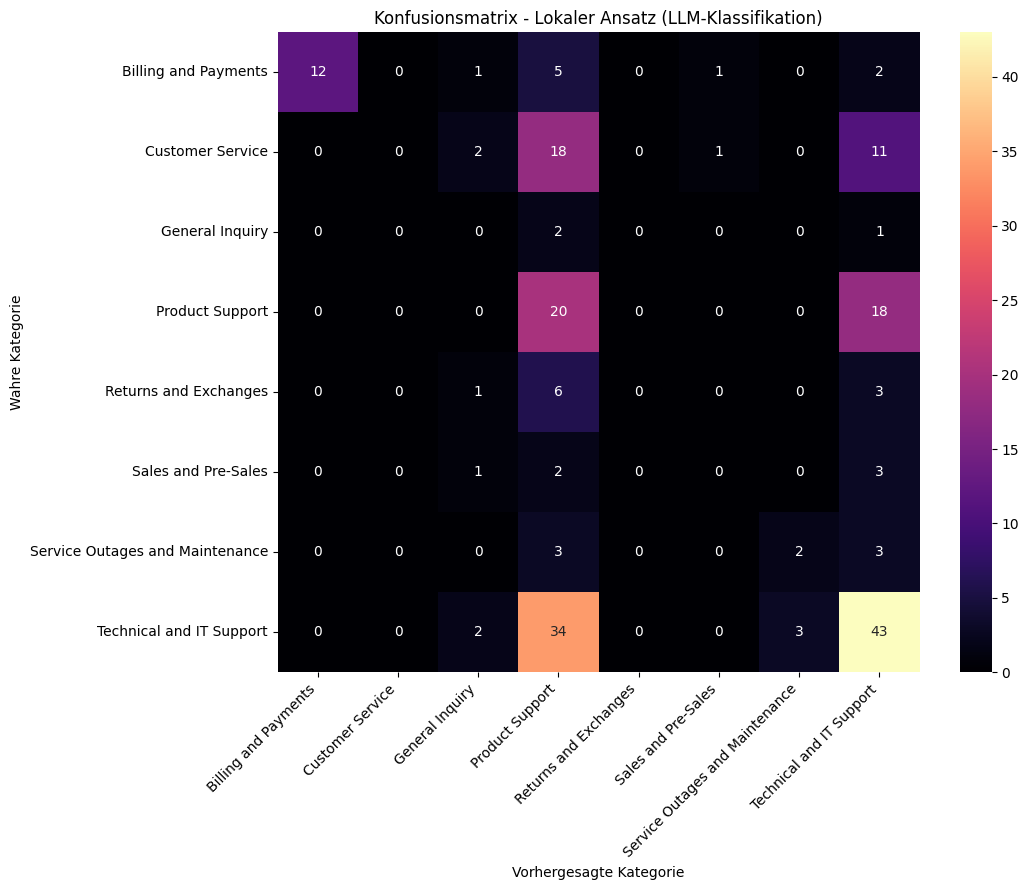

In [ ]:
# Die Matrix wird über alle Kategorien aufgespannt, auch wenn einzelne in der Stichprobe
# selten sind, damit die Achsen mit dem Cloud-Notebook vergleichbar bleiben.
labels = KATEGORIEN
cm = confusion_matrix(valid["true_category"], valid["category"], labels=labels)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma",
            xticklabels=labels, yticklabels=labels)
plt.title("Konfusionsmatrix - Lokaler Ansatz (LLM-Klassifikation)")
plt.xlabel("Vorhergesagte Kategorie")
plt.ylabel("Wahre Kategorie")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Auswertung 2: Kosten (Rechenzeit statt Token-Entgelt)

Hier liegt der konzeptionell bedeutsamste Unterschied zum Cloud-Ansatz. Während dort je
verarbeitetem Token ein Entgelt anfällt und sich die Kosten unmittelbar aus dem Token-Verbrauch
ergeben, entstehen im lokalen Betrieb keine nutzungsabhängigen Gebühren: Das Modell ist einmal
heruntergeladen und läuft auf bereits vorhandener Hardware. Die eigentliche Kostengröße ist
daher die **aufgewendete Rechenzeit**, denn sie bindet das Gerät, verbraucht Energie und begrenzt
den möglichen Durchsatz. Aus der durchschnittlichen Verarbeitungszeit je Ticket lässt sich
hochrechnen, wie lange die Klassifikation des gesamten Datensatzes von 20.000 Tickets auf dieser
Hardware in Anspruch nähme – eine Zahl, die der Geldkosten-Hochrechnung des Cloud-Ansatzes als
Pendant gegenübersteht.

Ergänzend wird der verarbeitete Token-Umfang ausgewiesen. Er dient hier nicht der Abrechnung,
sondern der Vergleichbarkeit: Da Prompt und Ticketinhalte identisch sind, sollte der
Eingabe-Umfang ähnlich zum Cloud-Ansatz ausfallen, was die Gegenüberstellung der reinen
Verarbeitungsgeschwindigkeit beider Ansätze erst sauber interpretierbar macht.

In [ ]:
# Mittlere Verarbeitungszeit je Ticket als Grundlage der Hochrechnung. Herangezogen werden
# alle Tickets mit gültiger Latenzmessung.
zeiten = results_df["latency_s"].dropna()
zeit_pro_ticket = zeiten.mean()

# Hochrechnung auf den vollständigen Datensatz, ausgedrückt in Sekunden, Minuten und Stunden,
# da die lokale Verarbeitung großer Mengen erhebliche Zeiträume beanspruchen kann.
hochrechnung_s = zeit_pro_ticket * len(df)
hochrechnung_min = hochrechnung_s / 60
hochrechnung_h = hochrechnung_min / 60

print(f"Mittlere Rechenzeit je Ticket   : {zeit_pro_ticket:.2f} s")
print(f"Rechenzeit Stichprobe ({len(zeiten)} Tickets): {zeiten.sum():.1f} s")
print(f"Hochrechnung auf {len(df)} Tickets : "
      f"{hochrechnung_s:.0f} s  (~{hochrechnung_min:.0f} min / ~{hochrechnung_h:.1f} h)")
print()
print("Hinweis: Im lokalen Betrieb fallen keine Token-Entgelte an; die Kosten bestehen in der")
print("Bindung der Hardware über den genannten Zeitraum sowie im damit verbundenen Energiebedarf.")

Mittlere Rechenzeit je Ticket   : 8.91 s
Rechenzeit Stichprobe (200 Tickets): 1782.8 s
Hochrechnung auf 19662 Tickets : 175262 s  (~2921 min / ~48.7 h)

Hinweis: Im lokalen Betrieb fallen keine Token-Entgelte an; die Kosten bestehen in der
Bindung der Hardware über den genannten Zeitraum sowie im damit verbundenen Energiebedarf.


Token im Mittel je Ticket : 252.9 Input + 17.5 Output


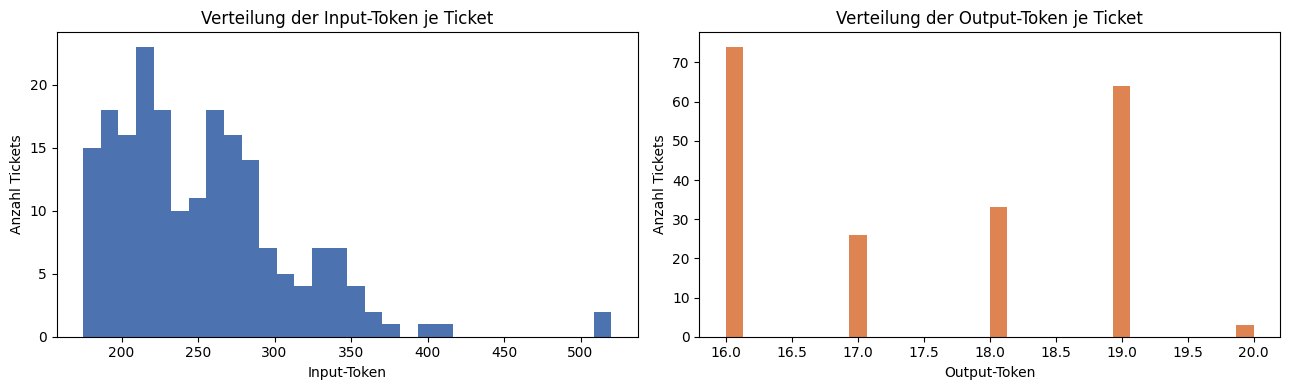

In [ ]:
# Sofern der Dienst Token-Zahlen zurückmeldet, wird ihr Umfang zur Einordnung dargestellt.
# Dies erlaubt den Abgleich des Verarbeitungsumfangs mit dem Cloud-Ansatz.
mit_tokens = results_df[results_df["input_tokens"].notna()]

if len(mit_tokens) > 0:
    mittel_input = mit_tokens["input_tokens"].mean()
    mittel_output = mit_tokens["output_tokens"].mean()
    print(f"Token im Mittel je Ticket : {mittel_input:.1f} Input + {mittel_output:.1f} Output")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.hist(mit_tokens["input_tokens"], bins=30, color="#4c72b0")
    ax1.set_title("Verteilung der Input-Token je Ticket")
    ax1.set_xlabel("Input-Token")
    ax1.set_ylabel("Anzahl Tickets")

    ax2.hist(mit_tokens["output_tokens"].dropna(), bins=30, color="#dd8452")
    ax2.set_title("Verteilung der Output-Token je Ticket")
    ax2.set_xlabel("Output-Token")
    ax2.set_ylabel("Anzahl Tickets")
    plt.tight_layout()
    plt.show()
else:
    print("Der Dienst hat keine Token-Zahlen zurückgemeldet; dieser Abschnitt entfällt.")

## Auswertung 3: Latenz

Die Latenz beschreibt die Zeit von der Absendung einer Anfrage bis zum Eintreffen der Antwort.
Im lokalen Betrieb entspricht sie nahezu vollständig der reinen Inferenzzeit auf der CPU, da
keine nennenswerte Netzwerkstrecke zu überbrücken ist. Für eine belastbare Einordnung werden
neben dem Mittelwert auch der Median und das 95.-Perzentil betrachtet, da die Verarbeitungszeit
über die Tickets streut: Längere Tickets erfordern mehr Rechenschritte und ziehen damit
einzelne Werte nach oben, weshalb der Median das typische Verhalten besser abbildet als der
Mittelwert. Das 95.-Perzentil gibt an, wie lange die langsamsten Anfragen dauern – eine für die
Auslegung von Zeitlimits relevante Größe.

Zu beachten ist, dass der erste, aufwärmende Aufruf die Ladezeit des Modells enthielt; sein Wert
liegt deutlich über dem der übrigen und wird daher für die folgende Betrachtung des regulären
Verhaltens ausgeklammert.

In [ ]:
# Der erste Aufruf enthielt die einmalige Ladezeit des Modells und wird daher von der
# Betrachtung des regulären Laufzeitverhaltens ausgenommen.
latenzen = results_df["latency_s"].dropna().tolist()
latenzen_regulaer = latenzen[1:] if len(latenzen) > 1 else latenzen

mittel = statistics.mean(latenzen_regulaer)
median = statistics.median(latenzen_regulaer)
p95 = sorted(latenzen_regulaer)[int(0.95 * len(latenzen_regulaer)) - 1]
minimum = min(latenzen_regulaer)
maximum = max(latenzen_regulaer)

print(f"Latenz Mittelwert  : {mittel:.2f} s")
print(f"Latenz Median      : {median:.2f} s")
print(f"Latenz 95-Perzentil: {p95:.2f} s")
print(f"Latenz Min / Max   : {minimum:.2f} s / {maximum:.2f} s")
print()
# Im sequenziellen lokalen Betrieb entspricht die summierte Latenz nahezu der Wanduhrzeit.
print(f"Summierte Latenz (alle Aufrufe): {sum(latenzen):.1f} s")
print(f"Tatsächliche Wanduhrzeit des Laufs: {wall_time:.1f} s")

Latenz Mittelwert  : 8.94 s
Latenz Median      : 8.25 s
Latenz 95-Perzentil: 15.45 s
Latenz Min / Max   : 3.40 s / 28.32 s

Summierte Latenz (alle Aufrufe): 1782.8 s
Tatsächliche Wanduhrzeit des Laufs: 1782.8 s


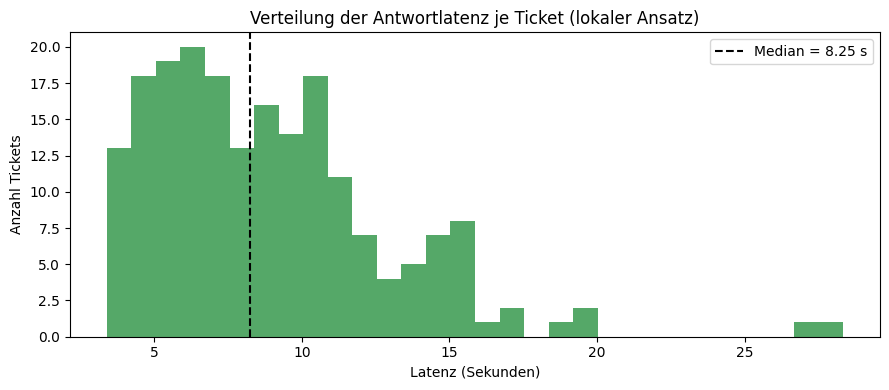

In [ ]:
# Histogramm der regulären Latenzverteilung mit eingezeichnetem Median zur schnellen Orientierung.
plt.figure(figsize=(9, 4))
plt.hist(latenzen_regulaer, bins=30, color="#55a868")
plt.axvline(median, color="black", linestyle="--", label=f"Median = {median:.2f} s")
plt.title("Verteilung der Antwortlatenz je Ticket (lokaler Ansatz)")
plt.xlabel("Latenz (Sekunden)")
plt.ylabel("Anzahl Tickets")
plt.legend()
plt.tight_layout()
plt.show()

## Zusammenfassung der Messgrößen

Die folgende Tabelle bündelt die erhobenen Kennzahlen, sodass sie unmittelbar in den Vergleich
mit dem Cloud-Ansatz übernommen werden können. Anstelle der Geldkosten je Ticket tritt hier die
Rechenzeit, was den unterschiedlichen Kostencharakter beider Ansätze unmittelbar widerspiegelt.

In [ ]:
zusammenfassung = pd.DataFrame([
    {"Kriterium": "Modell (lokal)", "Wert": MODEL},
    {"Kriterium": "Accuracy", "Wert": f"{accuracy:.3f}"},
    {"Kriterium": "Rechenzeit je Ticket (s)", "Wert": f"{zeit_pro_ticket:.2f}"},
    {"Kriterium": f"Hochrechnung {len(df)} Tickets (min)", "Wert": f"{hochrechnung_min:.0f}"},
    {"Kriterium": "Latenz Median (s)", "Wert": f"{median:.2f}"},
    {"Kriterium": "Latenz 95-Perzentil (s)", "Wert": f"{p95:.2f}"},
    {"Kriterium": "Ungültige Antworten", "Wert": f"{n_fehler} / {len(results_df)}"},
])
zusammenfassung

,Kriterium,Wert
0,Modell (lokal),qwen2.5:3b
1,Accuracy,0.385
2,Rechenzeit je Ticket (s),8.91
3,Hochrechnung 19662 Tickets (min),2921
4,Latenz Median (s),8.25
5,Latenz 95-Perzentil (s),15.45
6,Ungültige Antworten,0 / 200


### Einordnung

Der lokale Ansatz erbringt die Klassifikation ohne Übertragung der Ticketdaten an einen externen
Anbieter und ohne nutzungsabhängige Entgelte: Das Modell läuft vollständig auf bereits
vorhandener Hardware, weshalb die Daten das Gerät nicht verlassen und der Datenschutz
strukturell (nicht erst vertraglich) gewahrt ist. Diesem Gewinn an Datensouveränität und der
Unabhängigkeit von laufenden Kosten stehen jedoch deutliche Einschränkungen gegenüber, die sich
in den erhobenen Messgrößen niederschlagen.

Erstens fällt die Latenz je Anfrage höher aus und summiert sich, da auf einer einzelnen CPU ohne Grafikkarte
sequenziell gearbeitet werden muss, zu erheblichen Gesamtlaufzeiten, während der Cloud-Ansatz
denselben Umfang durch Parallelisierung in einem Bruchteil der Wanduhrzeit bewältigt. Der zuvor
sichtbare Anteil ungültiger Antworten verweist zudem auf die geringere Zuverlässigkeit kompakter
Modelle im strikten Befolgen des geforderten Ausgabeformats. 

Die hier gemessenen Werte für Qualität, Rechenzeit und Latenz bilden, zusammen mit den
entsprechenden Größen des Cloud-Notebooks, die empirische Grundlage, um die im Projekt
aufgeworfenen Trade-offs am konkreten Anwendungsfall sichtbar zu machen: Datensouveränität und
Kostenunabhängigkeit auf Seiten der lokalen Lösung stehen höherer Geschwindigkeit und Skalierbarkeit auf
Seiten des Cloud-Ansatzes gegenüber, wobei die je nach Einsatzkontext unterschiedliche Gewichtung
dieser Faktoren über die sinnvolle Wahl entscheidet.